In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# ── Style ──────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":      "serif",
    "font.serif":       ["Times New Roman", "DejaVu Serif"],
    "font.size":        10,
    "axes.spines.top":  False,
    "axes.spines.right": False,
    "axes.grid":        False,
    "xtick.direction":  "out",
    "ytick.direction":  "out",
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "axes.linewidth":   0.6,
    "lines.linewidth":  0.9,
    "legend.frameon":   False,
    "legend.fontsize":  9,
})

In [ ]:
# FIGURE: Main Figure: M0 vs Key Ablations
## This should probably be a table actually

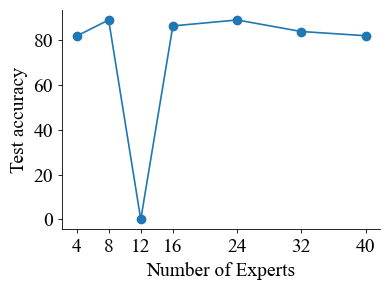

In [ ]:
# FIGURE: Num Experts Sweep (Line Plot)
## Ideally is a mountain curve around 22ish?

A5_num_experts_sweep_dict = {
    4: 81.80,   # (at 20 was 78.17...)
    8: 88.99,  # (at 20 was 89.42 lol)
    12: 0.0, 
    16: 86.34, 
    #20: 88.42, 
    24: 88.99, 32: 83.84, 40: 81.96, 
}

TITLE_FONTSIZE = 16
LABEL_FONTSIZE = 13 + 1

# ── Figure layout ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(4.0, 3.0))

ax.plot(
    list(A5_num_experts_sweep_dict.keys()),
    list(A5_num_experts_sweep_dict.values()),
    #color=color,
    #label=label,
    linewidth=1.2,
)
ax.scatter(
    list(A5_num_experts_sweep_dict.keys()),
    list(A5_num_experts_sweep_dict.values()),
    #color=color,
    #label=label,
)

ax.set_xticks(list(A5_num_experts_sweep_dict.keys()))
ax.set_xlabel("Number of Experts", fontsize=LABEL_FONTSIZE)
ax.set_ylabel("Test accuracy", fontsize=LABEL_FONTSIZE)
ax.tick_params(axis='both', labelsize=LABEL_FONTSIZE)
ax.yaxis.set_major_locator(plt.MaxNLocator(5))

plt.tight_layout()

# ── Export ─────────────────────────────────────────────────────────────────────
# plt.savefig("num_experts_sweep.pdf", dpi=500, bbox_inches="tight")
#plt.savefig("num_experts_sweep.png", dpi=500, bbox_inches="tight")
plt.show()

In [ ]:
# FIGURE: K-shot N-way Performance Grid (Line Plot)
## Need to show best baseline here as well

In [26]:
# FIGURE: Eval Num Steps Sweep (Line Plot)
## I dont have error bars for this rn... maybe the json has the mean and std?

# A11 eval sweep (LR=0.01)
A11_eval_sweep_dict = {1: 37.60, 5: 49.93, 10: 64.29, 25: 78.47, 50: 81.08, 100: 81.44}  #, 150: 81.58, 200: 81.46}

# A7 eval sweep (LR=0.001)
# --> gonna ignore this one because it was not using paired corresponding user-specific models
A7_eval_sweep_dict = {1: 39.35, 5: 63.15, 10: 72.80, 25: 77.23, 50: 78.13, 100: 78.27, 150: 78.30, 200: 78.41}

# M0 eval sweep
M0_eval_sweep_dict = {1: 57.73, 5: 86.40, 10: 90.88, 25: 92.57, 50: 92.93, 100: 93.39} #, 150: 93.65}



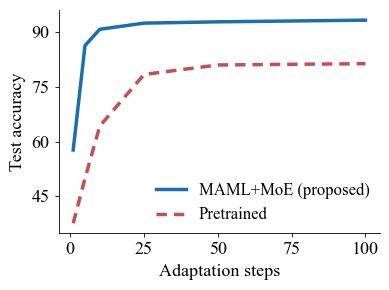

In [ ]:
COLORS = ["#1a6faf", "#2ca25f", "#c44e52"]
DASHES = [(), (6, 2), (3, 2)]

TITLE_FONTSIZE = 16
LABEL_FONTSIZE = 13

# ── Figure layout ──────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(4.0, 3.0))

lines = [
    (M0_eval_sweep_dict,  "MAML+MoE (proposed)",         COLORS[0], DASHES[0]),
    #(A7_eval_sweep_dict,  "Subject-specific",   COLORS[1], DASHES[1]),
    (A11_eval_sweep_dict, "Pretrained", COLORS[2], DASHES[2]),
]

for data, label, color, dash in lines:
    ax.plot(
        list(data.keys()),
        list(data.values()),
        color=color,
        dashes=dash,
        label=label,
        linewidth=2.5,
    )

ax.set_xlabel("Adaptation steps", fontsize=LABEL_FONTSIZE)
ax.set_ylabel("Test accuracy", fontsize=LABEL_FONTSIZE)
ax.tick_params(axis='both', labelsize=LABEL_FONTSIZE)
ax.yaxis.set_major_locator(plt.MaxNLocator(5))
ax.legend(loc="lower right", handlelength=1.8, borderaxespad=0.2, fontsize=LABEL_FONTSIZE-1)

plt.tight_layout()

# ── Export ─────────────────────────────────────────────────────────────────────
# plt.savefig("eval_steps_sweep.pdf", dpi=500, bbox_inches="tight")
#plt.savefig("eval_steps_sweep.png", dpi=500, bbox_inches="tight")
plt.show()